In [ ]:
from senseai import SenseAI
import cv2
import json
import numpy as np
import os

### test using webcam



In [ ]:
SenseAI_version_path = r"C:\Program Files\SenseAI\SenseAI 2026.1.1"

current_dir = os.getcwd()

s = SenseAI(os.path.join(SenseAI_version_path,"SenseAI.dll"))

sg = s.hw.add_scan_generator("WCScanGen", "QDMock", {
    "ScanSize": [
        1536,
        1024
    ],
    "DwellTime": 0.010,
    "Pattern": "Raster",
    "Sampling": 1.0,
    "ResetBuffer": True,
})


s.hw.add_detector("WCDetector", "ScanGenerator", sg["Name"], {
    "Input": 0,
    "QDType": "qd_analogue"
})



{'Channels': 1,
 'Delay': 30,
 'FlybackPixels': 0,
 'ForceSupportVD': False,
 'FrameSize': [0, 0],
 'Generator': 'WCScanGen',
 'Input': 0,
 'Name': 'WCDetector',
 'QDType': 'qd_analogue',
 'ScanSize': [640, 480],
 'SupportsVirtualDetectors': False,
 'Type': 'ScanGenerator'}

In [3]:

s.hw.init_scan_generator("WCScanGen")



'Initialised'

In [4]:
s.hw.update_scan_generator("WCScanGen",
                           {
                               "Pattern":"Linehop",\
                               "Sampling":0.25,
                               "ResetBuffer":True
                           })

{'AccelerationVoltage': 0.0,
 'BeamParkPosition': '0, 0',
 'ConvergenceSemiAngle': 0.0,
 'DwellTime': 0.01,
 'Firmware': '',
 'FlybackPixels': 0,
 'FlybackTime': 0.001,
 'FrameAverage': 1,
 'FrameCounter': 1,
 'FrameNumber': 0,
 'Generator': 1,
 'Hardware': True,
 'ImageMode': 0,
 'Initialised': True,
 'Label': '',
 'LineAverage': 1,
 'Name': 'WCScanGen',
 'Pattern': 'Linehop',
 'Paused': False,
 'ResetBuffer': True,
 'RotationAngle': 0.0,
 'Sampling': 0.25,
 'ScanSize': [640, 480],
 'ScanSizeHasFlybackAdjustment': False,
 'Seed': 0,
 'Type': 'QDMock'}

In [ ]:

scan_gen_settings = {
    "Pattern":"Linehop",\
    "Sampling":0.25,
    "ResetBuffer":True
                           }


output = s.hw.scan_generator_capture("WCScanGen",scan_gen_settings=scan_gen_settings,location=r"C:\Code\SenseAI_Project")

In [ ]:
print(output)

In [5]:
output2 = s.hw.get_detector_image("WCDetector")

In [6]:
print(output2)

(array([[  1670,   1156, -32768, ..., -32768, -32768, -32768],
       [-32768, -32768,   1413, ..., -32768, -32768, -32768],
       [-32768, -32768, -32768, ...,  -1671,  -1414, -32768],
       ...,
       [-32768,   2184, -32768, ..., -32768, -32768, -32768],
       [  2441, -32768,   1927, ..., -32768, -32768, -32768],
       [-32768, -32768, -32768, ...,  32767,  32767,  32767]],
      shape=(480, 640), dtype=int16), array([[1, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 1]], shape=(480, 640), dtype=uint8))


In [7]:
img = output2[0]
mask = output2[1]

In [8]:
import matplotlib.pyplot as plt

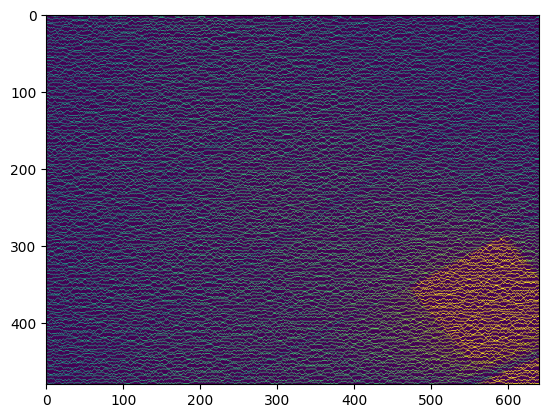

In [9]:
plt.imshow(img)
plt.show()

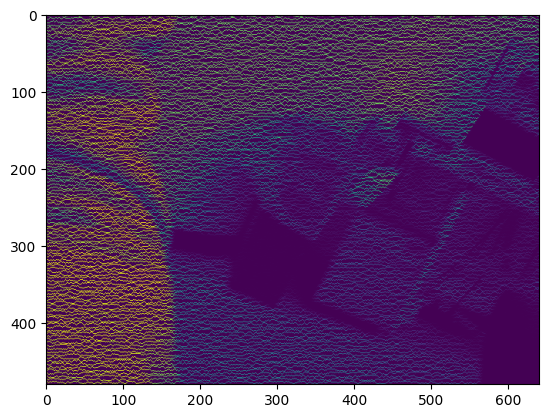

In [24]:
output3 = s.hw.get_detector_image("WCDetector")

img1 = output3[0]
mask1 = output3[1]

plt.imshow(img1)
plt.show()

In [ ]:
s.add_image("img0",img,mask)

In [ ]:
from senseai import quick_recon

In [ ]:
img_to_use = "img0"


dict_name, train, recon = quick_recon(s, image=img_to_use, patch_shape=[10, 10, 1, 1], dict_size=36, dict_kwargs={"OnesElement": True})

try:
    while True:
        image = s.get_image_buffer(img_to_use, "Input")
        reference_data = s.get_image_array(img_to_use, "Reference")
        recon = s.get_image_buffer(img_to_use, "Reconstruction")
        dictionary = s.get_gallery_buffer(dict_name, "Default", 6.0)

        cv2.imshow("Image", image)
        cv2.imshow("Reference", reference_data)
        cv2.imshow("Reconstruction", recon)
        cv2.waitKey(1000)
except KeyboardInterrupt:
    pass

In [ ]:
# for _ in range(200):
#     buf, mask = s.hw.get_detector_image("Test", "Buffer")
#     cv2.normalize(buf, buf, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
#     buf = buf.astype(np.uint8)
#     cv2.imshow("Webcam", buf)
#     cv2.waitKey(100)
# cv2.destroyAllWindows()